In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
import os

os.makedirs("final_figures", exist_ok=True)

In [52]:
df = pd.read_csv("saudi_data_jobs_cleaned.csv")

In [53]:
df.shape

(45, 15)

In [54]:
tools = (
    df["tools"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

tools

,count
tools,
SQL,23
Python,18
Excel,16
Power BI,16
dashboards,14
Tableau,14
reporting tools,7
PyTorch,5
TensorFlow,5


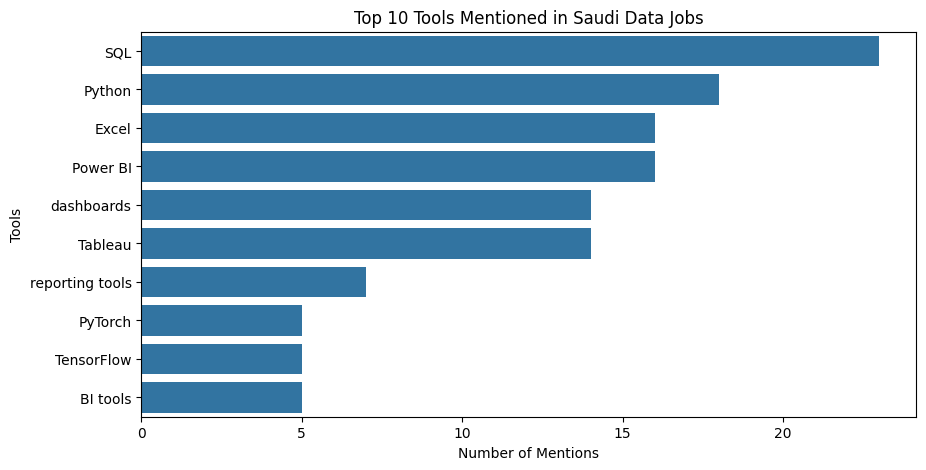

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=tools.values,
    y=tools.index
)

plt.title("Top 10 Tools Mentioned in Saudi Data Jobs")
plt.xlabel("Number of Mentions")
plt.ylabel("Tools")

plt.show()

In [56]:
plt.savefig("final_figures/top_tools_final.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [57]:
skills = (
    df["skills"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

skills

,count
skills,
reporting,14
data analysis,13
problem solving,12
trend analysis,12
data governance,12
data integrity,12
data validation,10
dashboard development,9
data accuracy,9


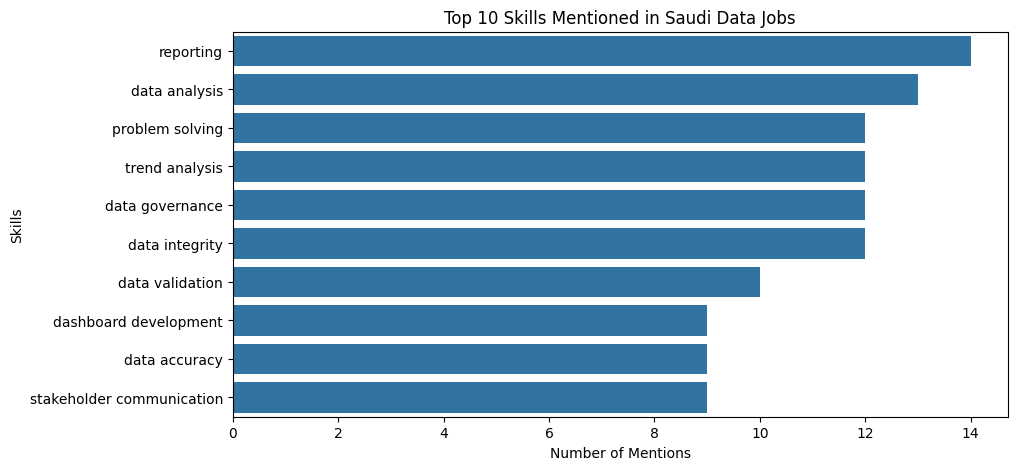

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=skills.values,
    y=skills.index
)

plt.title("Top 10 Skills Mentioned in Saudi Data Jobs")
plt.xlabel("Number of Mentions")
plt.ylabel("Skills")

plt.show()

In [59]:
plt.savefig("final_figures/top_skills_final.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [60]:
city_distribution = (
    df["city_cleaned"]
    .value_counts()
)

city_distribution

,count
city_cleaned,
Riyadh,28
Jeddah,10
Not specified,5
Mahd Adh Dhahab,1
King Abdullah Economic City,1


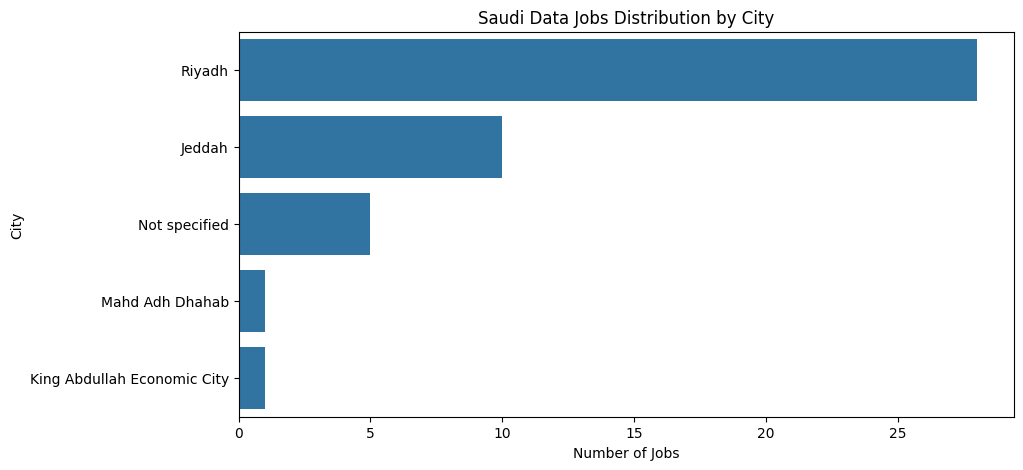

In [61]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=city_distribution.values,
    y=city_distribution.index
)

plt.title("Saudi Data Jobs Distribution by City")
plt.xlabel("Number of Jobs")
plt.ylabel("City")

plt.show()

In [62]:
plt.savefig("final_figures/city_distribution_final.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [63]:
role_distribution = (
    df["role_category"]
    .value_counts()
)

role_distribution

,count
role_category,
AI,8
BI,6
Data Analysis,5
Data Science,5
Performance Analytics,5
Governance,4
Business / Financial Analytics,3
Fraud Analytics,3
Research Analytics,2


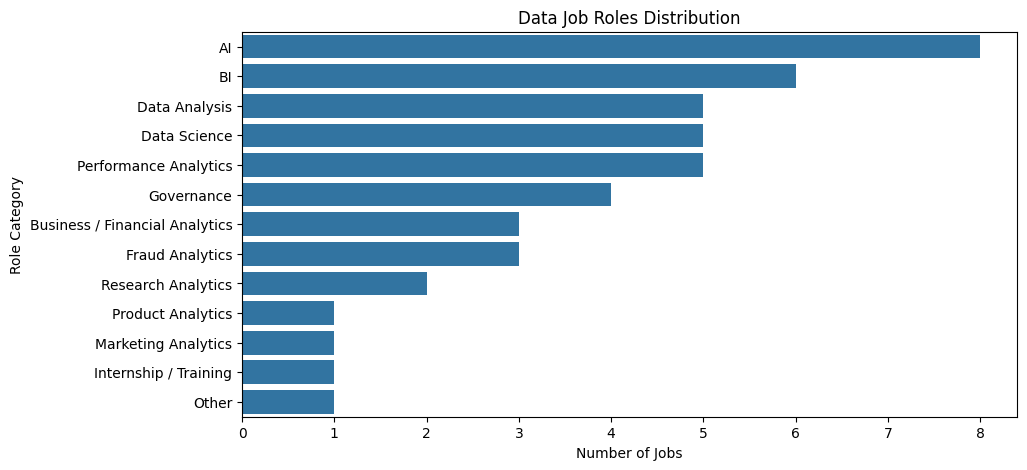

In [64]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=role_distribution.values,
    y=role_distribution.index
)

plt.title("Data Job Roles Distribution")
plt.xlabel("Number of Jobs")
plt.ylabel("Role Category")

plt.show()

In [65]:
plt.savefig("final_figures/role_category_final.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [66]:
experience_distribution = (
    df["experience_category"]
    .value_counts()
)

experience_distribution

,count
experience_category,
Entry Level,18
Mid-Level,13
Not Specified,10
Internship,3
Senior,1


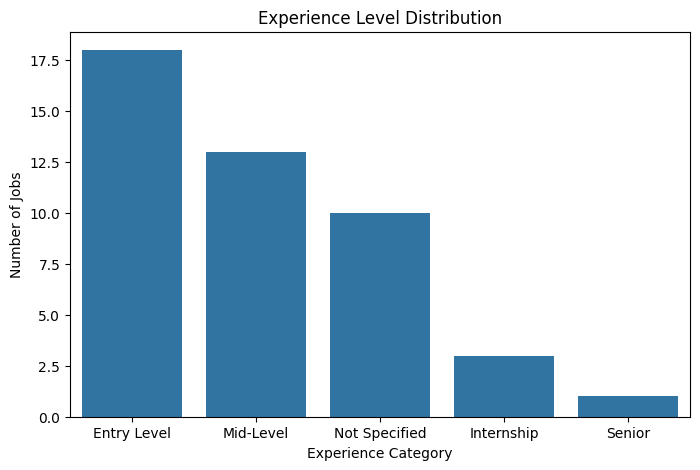

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=experience_distribution.index,
    y=experience_distribution.values
)

plt.title("Experience Level Distribution")
plt.xlabel("Experience Category")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=0)

plt.show()

In [68]:
plt.savefig("final_figures/experience_category_final.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [69]:
tools_role = (
    df[["role_category", "tools"]]
    .dropna()
)

tools_role["tools"] = tools_role["tools"].str.split(",")

tools_role = tools_role.explode("tools")

tools_role["tools"] = tools_role["tools"].str.strip()

In [70]:
tools_role_table = pd.crosstab(
    tools_role["role_category"],
    tools_role["tools"]
)

tools_role_table.head()

tools,AI frameworks,AI tools,AI training platforms,API integration,AWS,AWS Bedrock,AWS Redshift,Acquire,Airflow,Alteryx,...,regression,relational databases,reporting platforms,reporting tools,reports,sensors,statistical analysis tools,statistical modeling tools,statistical tools,survey data tools
role_category,,,,,,,,,,,,,,,,,,,,,
AI,1,0,1,0,1,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
BI,0,0,0,0,0,0,1,0,0,1,...,0,0,1,1,2,0,0,0,0,0
Business / Financial Analytics,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
Data Analysis,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Data Science,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,0,1,0,0


In [71]:
top_tools = (
    tools_role_table.sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)


heatmap_data = tools_role_table[top_tools]

heatmap_data

tools,SQL,Python,Power BI,Excel,Tableau,dashboards,reporting tools,BI tools,R,PyTorch
role_category,,,,,,,,,,
AI,2,5,2,0,2,1,0,0,1,5
BI,4,2,4,3,4,3,1,2,1,0
Business / Financial Analytics,1,1,1,2,1,2,1,1,1,0
Data Analysis,2,2,2,3,2,2,1,0,0,0
Data Science,4,5,3,1,3,0,0,0,1,0
Fraud Analytics,1,1,0,1,0,2,1,0,0,0
Governance,2,0,1,0,1,1,1,1,0,0
Internship / Training,0,0,0,0,0,0,0,0,0,0
Marketing Analytics,1,0,0,1,0,0,0,0,0,0


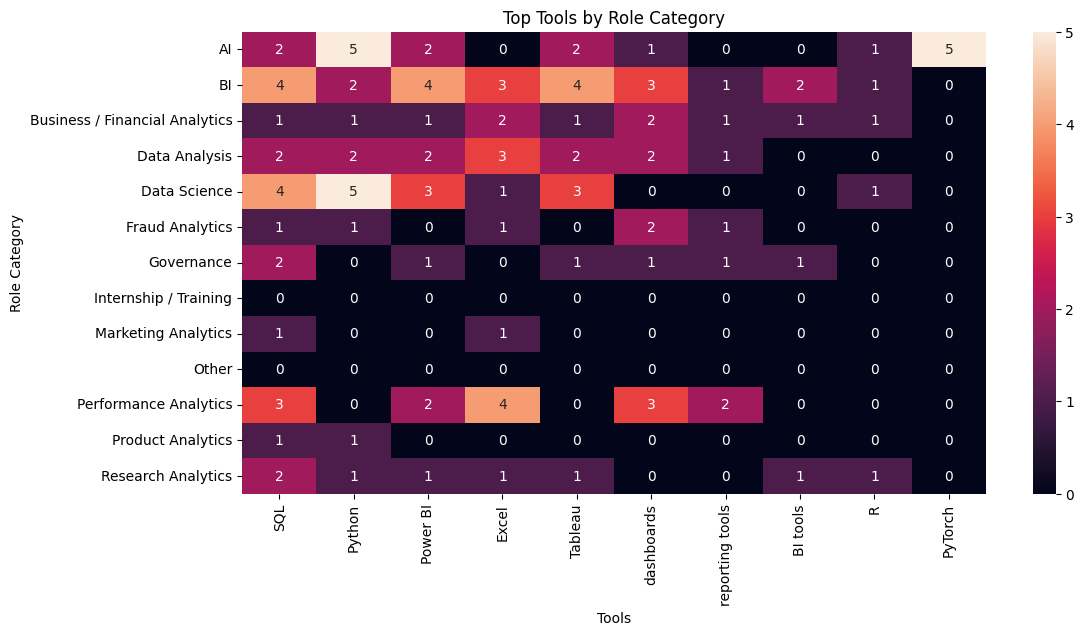

In [72]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d"
)

plt.title("Top Tools by Role Category")

plt.xlabel("Tools")
plt.ylabel("Role Category")

plt.show()

In [73]:
plt.savefig("final_figures/tools_by_role_heatmap_final.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [74]:
import matplotlib.pyplot as plt
import os

os.makedirs("final_figures", exist_ok=True)

for i, fig in enumerate(map(plt.figure, plt.get_fignums()), start=1):
    fig.savefig(
        f"final_figures/chart_{i}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Saved:", os.listdir("final_figures"))

Saved: ['top_skills_final.png', 'city_distribution_final.png', 'experience_category_final.png', 'role_category_final.png', 'tools_by_role_heatmap_final.png', 'top_tools_final.png']


In [75]:
import os
os.listdir("final_figures")

['top_skills_final.png',
 'city_distribution_final.png',
 'experience_category_final.png',
 'role_category_final.png',
 'tools_by_role_heatmap_final.png',
 'top_tools_final.png']

## Day 20 Summary

Updated the main project visualizations using the expanded dataset containing 45 Saudi data-related job postings.

Created updated charts for:

- Top tools.
- Top skills.
- City distribution.
- Role categories.
- Experience categories.
- Tools by role category.

The updated visualizations provide a clearer view of the Saudi data job market requirements and will be used for the final project documentation and dashboard development.